## 01 Land Base Context: South Dakota Tribal Agricultural Lands
**Series:** Tribal Agriculture & Land Health in South Dakota  
**Author:** Lilly Jones, PhD  
**Primary instructional focus:** Pine Ridge and Oglala Lakota  
**Regional context:** Public-data comparisons elsewhere in South Dakota; inclusion does not imply representation  
**Data Sources:** Census TIGER AIANNH

## Purpose
This notebook establishes the land base context for the series. Before any
agricultural analysis, we need to understand the physical scale, geography,
and jurisdiction structure of the lands being analyzed.

Pine Ridge and Rosebud together cover approximately 5,400 square miles, which is
larger than Connecticut. This scale, combined with the mixed-grass prairie
ecology of the southern South Dakota plains, shapes every agricultural
challenge and opportunity analyzed in this series.

## Research Questions
- What is the land area of each Tribal Nation in the study area?
- How are the reservations distributed geographically across South Dakota?
- What is the geographic relationship between Pine Ridge and Rosebud?

## A Note on Census Boundaries
> Census TIGER boundaries are used here for geographic analysis only. They
> represent federal statistical designations, not Tribal legal jurisdiction
> or Tribal self-definition. The Oglala Lakota Nation and Rosebud Sioux Tribe
> are sovereign nations whose territorial relationship to these lands predates
> federal mapping.

## Learning Objectives

By the end of this notebook, learners will be able to:

- distinguish statistical boundaries from jurisdiction
- inspect regional land-context coverage

## Prerequisites and Timing

Allow 75-100 minutes. Activate the project environment, read `docs/data_governance.md`, and complete the preceding notebook where applicable. Work in pairs and rotate analyst, data-steward, skeptic, and documentarian roles.

## Governance Checkpoint

This public-data notebook is an educational analysis with Pine Ridge as the primary instructional focus. Other Nations and geographies are regional context only. Do not add operational records, sensitive locations, personal information, or community knowledge. Results are screening-level and not approved OLC/OST conclusions.

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
from datetime import datetime

import contextily as ctx
import geopandas as gpd
gpd.options.io_engine = "fiona"
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from shapely.validation import make_valid

from src.data import constants
from src.data.constants import (
    SD_TRIBES_ALL, SD_TRIBES_PRIMARY, SD_TRIBES_SECONDARY,
    CENSUS_NAME_MAP, CENSUS_TO_COMMON,
    SD_BBOX, PINE_RIDGE_BBOX,
    CRS_GEOGRAPHIC, CRS_PROJECTED,
)
from src.indigenous.sovereignty import print_data_acknowledgment, generate_citations

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

print(f"Repo root : {REPO_ROOT}")
print(f"Analysis run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Repo root : C:\Users\gekek\Documents\olc-nifa-tas
Analysis run: 2026-09-03 14:21


In [2]:
# Print data acknowledgement at the top of every notebook
print_data_acknowledgment(source_keys=["census_aiannh"])


DATA GOVERNANCE ACKNOWLEDGMENT (DRAFT; LOCAL REVIEW PENDING)
This analysis uses data that describes Indigenous and Tribal lands,
communities, and agricultural and water systems. This project is
informed by reference frameworks whose local applicability remains under review:

OCAP®  : A Canadian First Nations framework included as a reference point;
  naming it does not mean it has been adopted locally.
  Reference: https://fnigc.ca/ocap-training/

CARE   : Data use must deliver Collective Benefit to Indigenous peoples,
  respect their Authority to Control, uphold Responsibility to
  communities, and center Ethics across the full data lifecycle.
  Reference: https://www.gida-global.org/care

FAIR   : Data is Findable, Accessible, Interoperable, and Reusable.
  FAIR governs technical standards; it does not determine local authority,
  ethics, permission, or release decisions.
  Reference: https://www.go-fair.org/fair-principles/

IEEE 2890-2025 : Recommended Practice for Provenance of I

## Load Census TIGER AIANNH Boundaries

In [3]:
# Download Census TIGER AIANNH 
import requests, zipfile, io

AIANNH_URL  = constants.CENSUS_AIAN_URL
CACHE_PATH  = constants.CACHE_DIR/"tl_2023_us_aiannh.geojson"

try:
    constants.CACHE_DIR.mkdir(parents=True, exist_ok=True)
except FileExistsError:
    pass

if CACHE_PATH.exists():
    all_aiannh = gpd.read_file(CACHE_PATH)
    print(f"Loaded from cache: {len(all_aiannh):,} AIANNH features")
else:
    print("Downloading Census TIGER AIANNH...")
    r = requests.get(AIANNH_URL, timeout=300)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        import tempfile
        with tempfile.TemporaryDirectory() as tmp:
            z.extractall(tmp)
            shp = next(Path(tmp).glob("*.shp"))
            all_aiannh = gpd.read_file(shp).to_crs(CRS_GEOGRAPHIC)
    all_aiannh.to_file(CACHE_PATH, driver="GeoJSON")
    print(f"Downloaded and cached: {len(all_aiannh):,} AIANNH features")

Loaded from cache: 862 AIANNH features


In [4]:
# Check names
# Find all TIGER records that mention South Dakota or known SD Tribe names
sd_keywords = ["Pine Ridge", "Rosebud", "Standing Rock", "Cheyenne River",
               "Lower Brule", "Crow Creek", "Lake Traverse", "Flandreau"]

matches = all_aiannh[
    all_aiannh["NAME"].str.contains("|".join(sd_keywords), case=False, na=False)
]
print(f"Matched {len(matches)} features")
print(matches["NAME"].tolist())

Matched 12 features
['Rosebud', 'Pine Ridge', 'Crow Creek', 'Cheyenne River', 'Lower Brule', 'Standing Rock', 'Flandreau', 'Lake Traverse', 'Rosebud', 'Cheyenne River', 'Lower Brule', 'Lake Traverse']


In [5]:
# Filter to South Dakota Tribes 
# Match on Census names, then add common names
census_names   = list(CENSUS_NAME_MAP.values())
sd_tribal_raw  = all_aiannh[all_aiannh["NAME"].isin(census_names)].copy()
sd_tribal_raw  = sd_tribal_raw.dissolve(by="NAME", as_index=False)
sd_tribal_raw["geometry"] = sd_tribal_raw.geometry.apply(
    lambda g: make_valid(g) if g is not None else g
)
sd_tribal_raw["common_name"] = sd_tribal_raw["NAME"].map(CENSUS_TO_COMMON)

# Compute area
sd_tribal_raw["area_km2"]   = sd_tribal_raw.to_crs(CRS_PROJECTED).geometry.area / 1e6
sd_tribal_raw["area_sq_mi"] = sd_tribal_raw["area_km2"] * 0.386102
sd_tribal_raw["is_primary"] = sd_tribal_raw["common_name"].isin(SD_TRIBES_PRIMARY)

# Projected centroids
centroids = sd_tribal_raw.to_crs(CRS_PROJECTED).geometry.centroid.to_crs(CRS_GEOGRAPHIC)
sd_tribal_raw["centroid_lon"] = centroids.x
sd_tribal_raw["centroid_lat"] = centroids.y

tribal_lands = sd_tribal_raw.reset_index(drop=True)

print(f"South Dakota Tribal Nations loaded: {len(tribal_lands)}")
print()
print(
    tribal_lands[["common_name", "area_km2", "area_sq_mi", "is_primary"]]
    .sort_values("area_km2", ascending=False)
    .to_string(index=False)
)

South Dakota Tribal Nations loaded: 8

            common_name     area_km2  area_sq_mi  is_primary
   Cheyenne River Sioux 11445.303666 4419.054636       False
          Oglala Lakota 11275.039648 4353.315358        True
    Standing Rock Sioux  9486.078416 3662.593849       False
          Rosebud Sioux  5427.443984 2095.546977       False
Sisseton Wahpeton Oyate  3907.473036 1508.683154       False
       Crow Creek Sioux  1194.914756  461.358977       False
      Lower Brule Sioux  1008.953689  389.559037       False
 Flandreau Santee Sioux     9.060057    3.498106       False


## Land Base Summary

In [6]:
# Land base statistics
total_area_km2   = tribal_lands["area_km2"].sum()
primary_area_km2 = tribal_lands[tribal_lands["is_primary"]]["area_km2"].sum()

# For reference: South Dakota total area
SD_AREA_KM2 = 199_729

print("LAND BASE SUMMARY")
print(f"  Total Tribal land in study: {total_area_km2:,.0f} km²")
print(f"                            : {total_area_km2 * 0.386102:,.0f} sq mi")
print(f"  As % of South Dakota      : {total_area_km2/SD_AREA_KM2 * 100:.1f}%")
print()
print(f"  Pine Ridge and Rosebud      : {primary_area_km2:,.0f} km²")
print(f"                            : {primary_area_km2 * 0.386102:,.0f} sq mi")
print()
print("By Tribal Nation:")
for _, row in tribal_lands.sort_values("area_km2", ascending=False).iterrows():
    flag = " * PRIMARY" if row["is_primary"] else ""
    print(f"  {row['common_name']:<35} {row['area_km2']:>8,.0f} km²  "
          f"({row['area_sq_mi']:>6,.0f} sq mi){flag}")

LAND BASE SUMMARY
  Total Tribal land in study: 43,754 km²
                            : 16,894 sq mi
  As % of South Dakota      : 21.9%

  Pine Ridge and Rosebud      : 11,275 km²
                            : 4,353 sq mi

By Tribal Nation:
  Cheyenne River Sioux                  11,445 km²  ( 4,419 sq mi)
  Oglala Lakota                         11,275 km²  ( 4,353 sq mi) * PRIMARY
  Standing Rock Sioux                    9,486 km²  ( 3,663 sq mi)
  Rosebud Sioux                          5,427 km²  ( 2,096 sq mi)
  Sisseton Wahpeton Oyate                3,907 km²  ( 1,509 sq mi)
  Crow Creek Sioux                       1,195 km²  (   461 sq mi)
  Lower Brule Sioux                      1,009 km²  (   390 sq mi)
  Flandreau Santee Sioux                     9 km²  (     3 sq mi)


## Maps

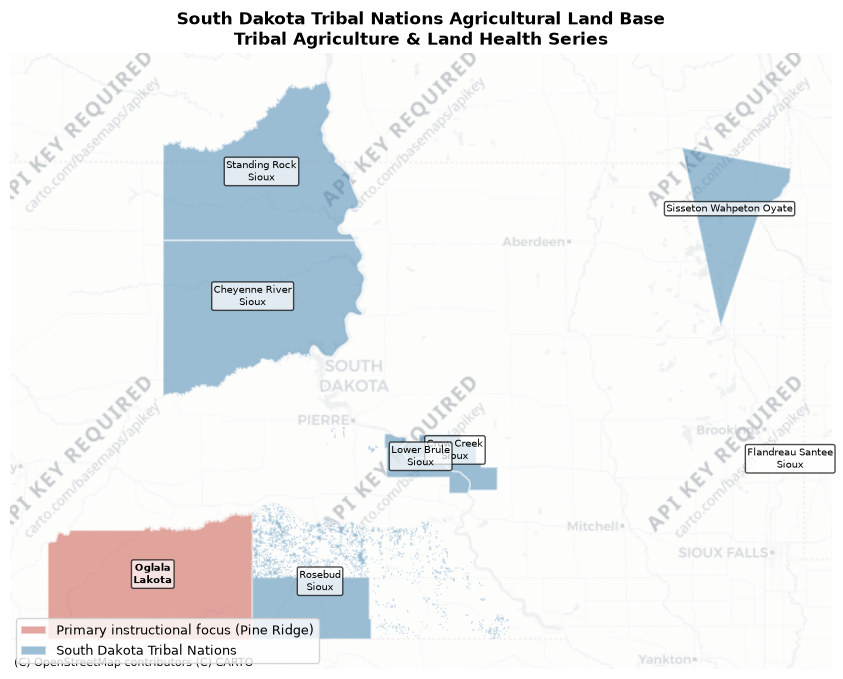

In [7]:
# Oceti Sakowin
fig, ax = plt.subplots(figsize=(13, 8))

PRIMARY_COLOR   = "#C0392B"   # deep red for Pine Ridge, Rosebud
SECONDARY_COLOR = "#2471A3"   # steel blue for other SD Tribes

for is_primary, color, label in [
    (True,  PRIMARY_COLOR,   "Primary instructional focus (Pine Ridge)"),
    (False, SECONDARY_COLOR, "South Dakota Tribal Nations"),
]:
    sub = tribal_lands[tribal_lands["is_primary"] == is_primary]
    if not sub.empty:
        sub.to_crs(3857).plot(
            ax=ax, color=color, alpha=0.45,
            edgecolor="white", linewidth=1.5,
            label=label,
        )

# Labels
for _, row in tribal_lands.iterrows():
    cx, cy = (
        gpd.GeoDataFrame(
            geometry=[row.geometry.centroid], crs=CRS_GEOGRAPHIC
        ).to_crs(3857).geometry.iloc[0].coords[0]
    )
    ax.annotate(
        row["common_name"].replace(" Sioux", "\nSioux").replace(" Lakota", "\nLakota"),
        (cx, cy), ha="center", fontsize=7,
        fontweight="bold" if row["is_primary"] else "normal",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
    )

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.4)
except Exception:
    pass

ax.set_axis_off()
ax.legend(loc="lower left", fontsize=9)
ax.set_title(
    "South Dakota Tribal Nations Agricultural Land Base\n"
    "Tribal Agriculture & Land Health Series",
    fontsize=12, fontweight="bold",
)

try:
    constants.OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
    fig_dir = constants.OUTPUTS_DIR/"figures"
    fig_dir.mkdir(exist_ok=True)
    fig.savefig(fig_dir/"01_sd_tribal_land_base.png", dpi=150, bbox_inches="tight")
except Exception:
    pass

plt.show()

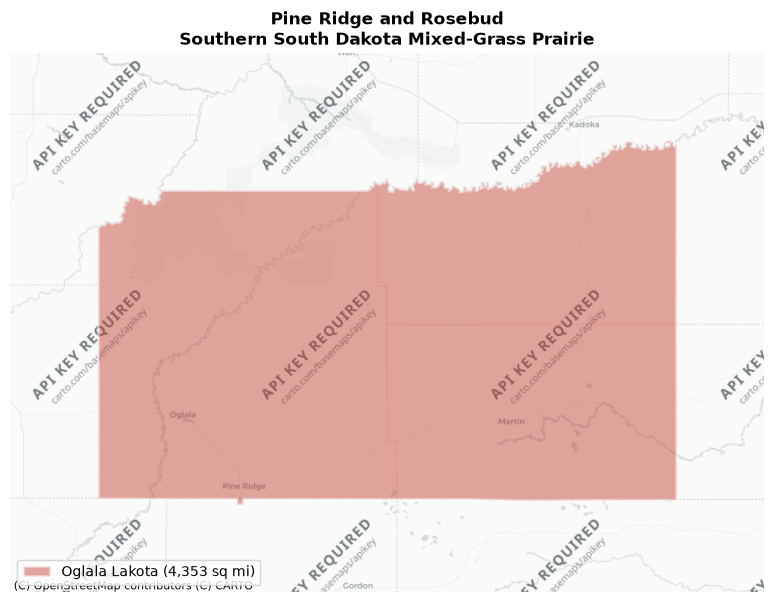

In [8]:
# Pine Ridge and Rosebud close-up
fig, ax = plt.subplots(figsize=(12, 7))

primary = tribal_lands[tribal_lands["is_primary"]].copy()

TRIBE_COLORS = {
    "Oglala Lakota": "#C0392B",
    "Rosebud Sioux": "#1A5276",
}

for _, row in primary.iterrows():
    color = TRIBE_COLORS.get(row["common_name"], "gray")
    gpd.GeoDataFrame(
        geometry=[row.geometry], crs=CRS_GEOGRAPHIC
    ).to_crs(3857).plot(
        ax=ax, color=color, alpha=0.45,
        edgecolor="white", linewidth=2,
        label=f"{row['common_name']} ({row['area_sq_mi']:,.0f} sq mi)",
    )

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception:
    pass

ax.set_axis_off()
ax.legend(loc="lower left", fontsize=10)
ax.set_title(
    "Pine Ridge and Rosebud\n"
    "Southern South Dakota Mixed-Grass Prairie",
    fontsize=12, fontweight="bold",
)

# Set extent to Pine Ridge focus bbox
pr_bounds = primary.to_crs(3857).total_bounds
pad = 30000  # 30km padding in meters
ax.set_xlim(pr_bounds[0] - pad, pr_bounds[2] + pad)
ax.set_ylim(pr_bounds[1] - pad, pr_bounds[3] + pad)

try:
    fig.savefig(fig_dir/"01_pine_ridge_rosebud_closeup.png", dpi=150, bbox_inches="tight")
except Exception:
    pass

plt.show()

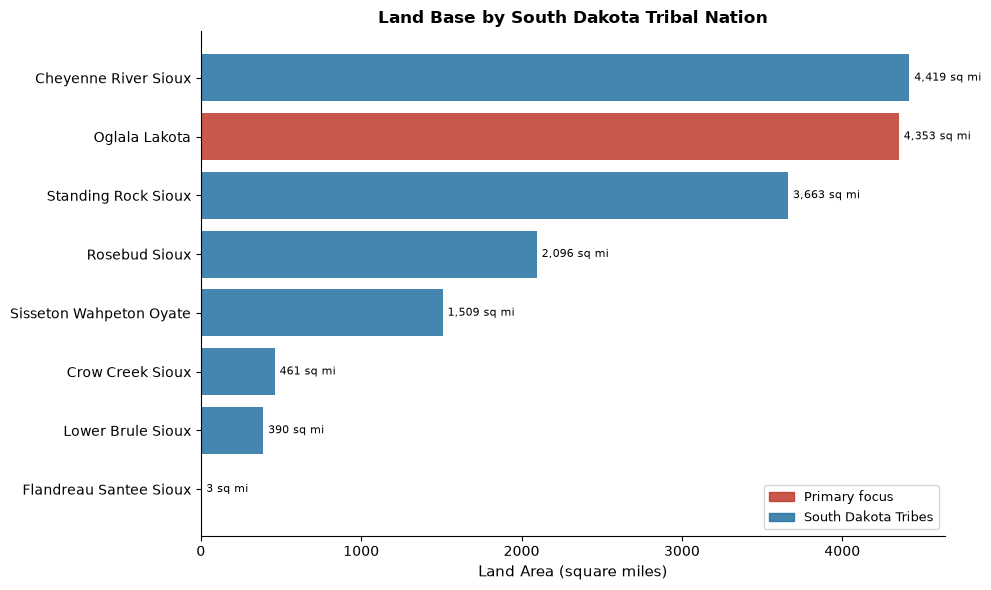

In [9]:
# Bar chart: Land area comparison 
fig, ax = plt.subplots(figsize=(10, 6))

sorted_lands = tribal_lands.sort_values("area_sq_mi", ascending=True)
colors = [
    PRIMARY_COLOR if is_p else SECONDARY_COLOR
    for is_p in sorted_lands["is_primary"]
]

ax.barh(
    sorted_lands["common_name"], sorted_lands["area_sq_mi"],
    color=colors, alpha=0.85,
)

# Annotation: sq miles
for _, row in sorted_lands.iterrows():
    ax.text(
        row["area_sq_mi"] + 30, sorted_lands.index.get_loc(_) if hasattr(sorted_lands.index, 'get_loc') else 0,
        f"{row['area_sq_mi']:,.0f} sq mi",
        va="center", fontsize=8,
    )

ax.set_xlabel("Land Area (square miles)", fontsize=11)
ax.set_title(
    "Land Base by South Dakota Tribal Nation",
    fontsize=12, fontweight="bold",
)
ax.legend(
    handles=[
        mpatches.Patch(color=PRIMARY_COLOR,   alpha=0.85, label="Primary focus"),
        mpatches.Patch(color=SECONDARY_COLOR, alpha=0.85, label="South Dakota Tribes"),
    ],
    fontsize=9,
)
import seaborn as sns
sns.despine(ax=ax)
plt.tight_layout()

try:
    fig.savefig(fig_dir/"01_land_area_comparison.png", dpi=150, bbox_inches="tight")
except Exception:
    pass

plt.show()

## Exports

In [10]:
# Exports
try:
    constants.OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
except FileExistsError:
    pass

# Tabular
tribal_lands[
    ["common_name", "NAME", "area_km2", "area_sq_mi",
     "centroid_lon", "centroid_lat", "is_primary"]
].to_csv(
    constants.OUTPUTS_DIR/"sd_tribal_land_base.csv", index=False
)
print("Exported to outputs/sd_tribal_land_base.csv")

# Spatial
tribal_lands[
    ["common_name", "NAME", "area_km2", "area_sq_mi", "is_primary", "geometry"]
].to_file(
    constants.OUTPUTS_DIR/"sd_tribal_land_base.geojson", driver="GeoJSON"
)
print("Exported to outputs/sd_tribal_land_base.geojson")

Exported to outputs/sd_tribal_land_base.csv
Exported to outputs/sd_tribal_land_base.geojson


## Summary and Findings

*(Fill in after running.)*

**What the data shows:**
- Total land area of South Dakota Tribal Nations in scope
- Pine Ridge is the [largest/second largest] reservation by land area, covering
  [X] square miles, approximately [Y] times the size of [reference area]
- Pine Ridge and Rosebud together represent [X]% of the total Tribal land base
  in the study, and share a contiguous southern SD border

**Why it matters for agriculture:**
Scale matters for agricultural analysis. Pine Ridge's [X] million acres of
mixed-grass prairie is one of the largest intact grassland systems in North
America. The land base determines the maximum potential for rangeland-based
agriculture and bison management, and shapes every water, drought, and
vegetation analysis in this series.

**Connection to the rest of the series:**
This notebook establishes the spatial foundation for all subsequent analysis.
The `tribal_lands` GeoDataFrame and `sd_tribal_land_base.geojson` are used
as the base layer in every subsequent notebook.

In [11]:
# Print citations
print(generate_citations(["census_aiannh"]))

REFERENCES AND DATA CITATIONS

Census TIGER AIANNH Boundaries:
  US Census Bureau, TIGER/Line Shapefiles (2023).
  URL: https://www.census.gov/cgi-bin/geo/shapefiles/index.php


## Learner Checkpoint

Choose one mapped boundary and state what it represents and cannot support.

## Interpretation Protocol

Separate **observation** from the selected public data, **interpretation** as a plausible explanation, **additional evidence** needed, and **decision authority** over thresholds, release, or action. Do not convert a regional proxy, monitoring gap, association, configured flag, or scenario into a Nation-specific, causal, operational, or policy conclusion.

## Contribution Activity

Improve one label, unit, provenance note, limitation, citation, or reproducibility check. Review it with a partner and explain what became more defensible.

## Evidence Record and Next Step

Record one result, source, geography, period, transformation, limitation, and question requiring additional evidence or locally authorized expertise. Proceed to the next numbered notebook where applicable.